<a href="https://colab.research.google.com/github/Solo-monD/CV_Project/blob/main/CV_Project_Final_With_Real_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch torchvision opencv-python matplotlib tqdm
!git clone https://github.com/facebookresearch/segment-anything.git
%cd segment-anything
!pip install -e .

Cloning into 'segment-anything'...
remote: Enumerating objects: 304, done.
remote: Total 304 (delta 0), reused 0 (delta 0), pack-reused 304 (from 1)
Receiving objects: 100% (304/304), 18.31 MiB | 39.98 MiB/s, done.
Resolving deltas: 100% (161/161), done.
/content/segment-anything
Obtaining file:///content/segment-anything
  Preparing metadata (setup.py) ... done
  Running setup.py develop for segment_anything


SAM

In [2]:
!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

--2026-05-04 19:46:16--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 3.171.22.33, 3.171.22.118, 3.171.22.68, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|3.171.22.33|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 375042383 (358M) [binary/octet-stream]
Saving to: ‘sam_vit_b_01ec64.pth’

sam_vit_b_01ec64.pt 100%[===================>] 357.67M  25.3MB/s    in 6.1s    

2026-05-04 19:46:23 (58.9 MB/s) - ‘sam_vit_b_01ec64.pth’ saved [375042383/375042383]



Import

In [3]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import cv2
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import xml.etree.ElementTree as ET
from tqdm import tqdm

In [4]:
from google.colab import drive
drive.mount('/content/drive')

DATA_ROOT = "/content/drive/MyDrive/NWPU/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Load SAM

In [5]:
from segment_anything import sam_model_registry

device = "cuda" if torch.cuda.is_available() else "cpu"

sam = sam_model_registry["vit_b"](checkpoint="sam_vit_b_01ec64.pth")
sam.to(device)

# Freeze SAM
for p in sam.parameters():
    p.requires_grad = False

Lightweight COBOT

In [6]:
class COBOT(nn.Module):
    def __init__(self, dim=256):
        super().__init__()
        self.proj = nn.Conv2d(dim, dim, 1)

    def forward(self, x):
        return self.proj(x)

Model

In [7]:
class SAM_COBOT(nn.Module):
    def __init__(self, sam):
        super().__init__()
        self.image_encoder = sam.image_encoder
        self.prompt_encoder = sam.prompt_encoder
        self.mask_decoder = sam.mask_decoder
        self.cobot = COBOT()

    def forward(self, image, boxes):
        with torch.no_grad():
            image_embedding = self.image_encoder(image)

        image_embedding = self.cobot(image_embedding)

        sparse, dense = self.prompt_encoder(
            points=None,
            boxes=boxes,
            masks=None,
        )

        masks, _ = self.mask_decoder(
            image_embeddings=image_embedding,
            image_pe=self.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse,
            dense_prompt_embeddings=dense,
            multimask_output=False,
        )

        return masks

NWPU Dataset Loader

In [16]:
import os, cv2, torch, numpy as np, re
from torch.utils.data import Dataset

class NWPUDataset(Dataset):
    def __init__(self, root, max_samples=50, size=1024):
        self.root = root
        self.size = size

        self.img_dir = os.path.join(root, "positive image set")
        self.ann_dir = os.path.join(root, "ground truth")

        self.samples = []

        for f in os.listdir(self.img_dir):
            if f.endswith(".jpg"):
                img_path = os.path.join(self.img_dir, f)
                txt_path = os.path.join(self.ann_dir, f.replace(".jpg", ".txt"))

                if os.path.exists(txt_path):
                    self.samples.append((img_path, txt_path))

        self.samples = self.samples[:max_samples]

        if len(self.samples) == 0:
            raise ValueError("No valid samples found")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, txt_path = self.samples[idx]

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        h_orig, w_orig = img.shape[:2]
        img = cv2.resize(img, (self.size, self.size))

        mask = np.zeros((self.size, self.size), dtype=np.float32)
        boxes = []

        with open(txt_path, "r") as f:
            for line in f:
                nums = list(map(int, re.findall(r'\d+', line)))

                if len(nums) < 4:
                    continue

                x1, y1, x2, y2 = nums[:4]

                # Scale
                x1 = int(x1 * self.size / w_orig)
                x2 = int(x2 * self.size / w_orig)
                y1 = int(y1 * self.size / h_orig)
                y2 = int(y2 * self.size / h_orig)

                boxes.append([x1, y1, x2, y2])
                mask[y1:y2, x1:x2] = 1.0

        # Safety fallback
        if len(boxes) == 0:
            boxes = [[0,0,1,1]]

        box = torch.tensor([boxes[0]]).float()

        img = torch.tensor(img).permute(2,0,1).float()/255.0
        mask = torch.tensor(mask).unsqueeze(0)

        return img, box, mask

DataLoader

In [17]:
dataset = NWPUDataset(DATA_ROOT, max_samples=50)
dataloader = DataLoader(dataset, batch_size=1, shuffle=True)

Loss & Metrics

In [18]:
def dice_loss(pred, target):
    pred = pred.sigmoid()
    inter = (pred * target).sum()
    return 1 - (2*inter+1)/(pred.sum()+target.sum()+1)

def loss_fn(pred, target):
    return F.binary_cross_entropy_with_logits(pred,target) + dice_loss(pred,target)

def compute_iou(pred, target):
    pred = (pred>0.5).float()
    inter = (pred*target).sum()
    union = pred.sum()+target.sum()-inter
    return (inter/(union+1e-6)).item()

def compute_dice(pred, target):
    pred = (pred>0.5).float()
    inter = (pred*target).sum()
    return ((2*inter)/(pred.sum()+target.sum()+1e-6)).item()

Training

In [19]:
model = SAM_COBOT(sam).to(device)

optimizer = torch.optim.Adam(model.cobot.parameters(), lr=1e-4)

losses, ious, dices = [], [], []

for epoch in range(5):
    model.train()
    total_loss, total_iou, total_dice = 0,0,0

    for img, box, mask in tqdm(dataloader):
        img, box, mask = img.to(device), box.to(device), mask.to(device)

        pred = model(img, box)

        pred = F.interpolate(pred, size=mask.shape[-2:], mode='bilinear')

        loss = loss_fn(pred, mask)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_iou += compute_iou(pred.sigmoid(), mask)
        total_dice += compute_dice(pred.sigmoid(), mask)

    losses.append(total_loss/len(dataloader))
    ious.append(total_iou/len(dataloader))
    dices.append(total_dice/len(dataloader))

    print(f"Epoch {epoch}: Loss={losses[-1]:.4f}, IoU={ious[-1]:.4f}, Dice={dices[-1]:.4f}")

100%|██████████| 50/50 [19:09<00:00, 22.99s/it]


Epoch 0: Loss=1.1028, IoU=0.1536, Dice=0.2402


100%|██████████| 50/50 [18:59<00:00, 22.79s/it]


Epoch 1: Loss=0.7610, IoU=0.4456, Dice=0.5798


100%|██████████| 50/50 [19:06<00:00, 22.93s/it]


Epoch 2: Loss=0.5918, IoU=0.5755, Dice=0.6946


100%|██████████| 50/50 [19:27<00:00, 23.35s/it]


Epoch 3: Loss=0.5121, IoU=0.6239, Dice=0.7310


100%|██████████| 50/50 [18:58<00:00, 22.77s/it]

Epoch 4: Loss=0.4817, IoU=0.6481, Dice=0.7481


Plots

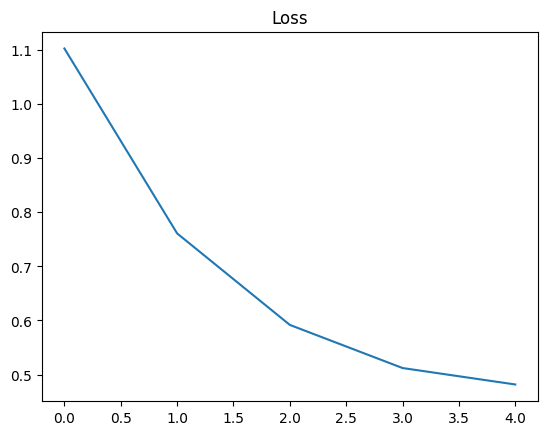

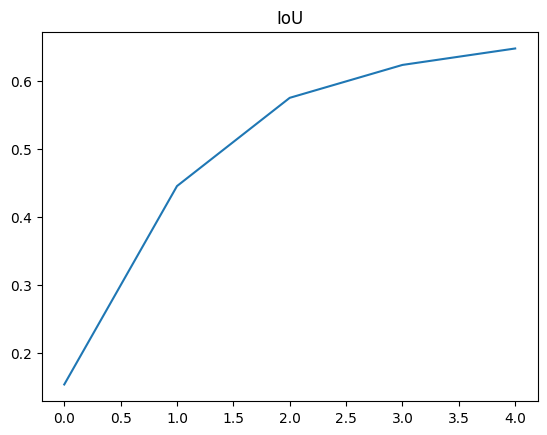

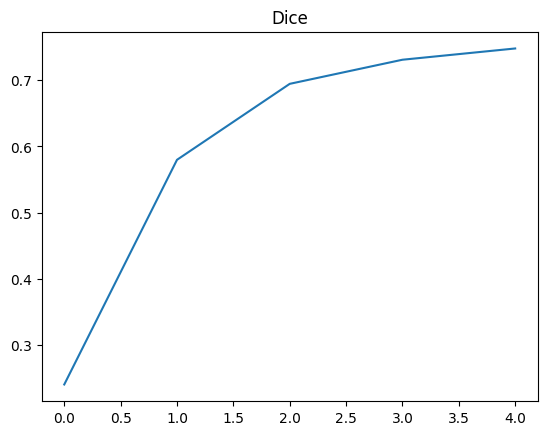

In [20]:
plt.plot(losses)
plt.title("Loss")
plt.show()

plt.plot(ious)
plt.title("IoU")
plt.show()

plt.plot(dices)
plt.title("Dice")
plt.show()

Qualitative Results

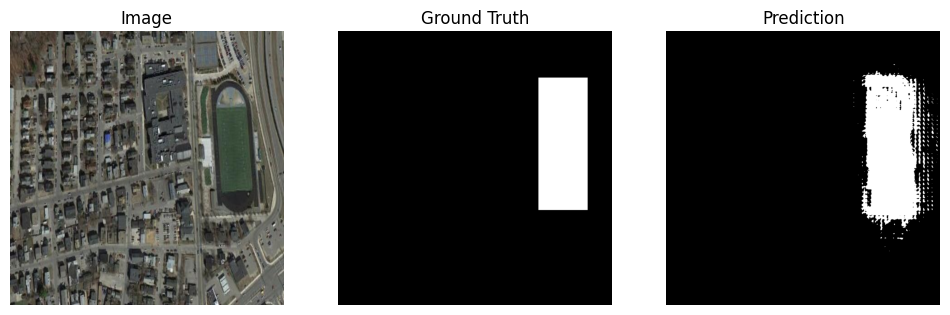

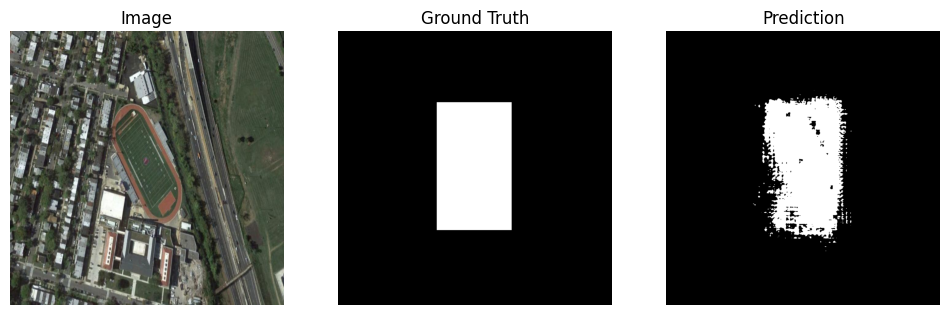

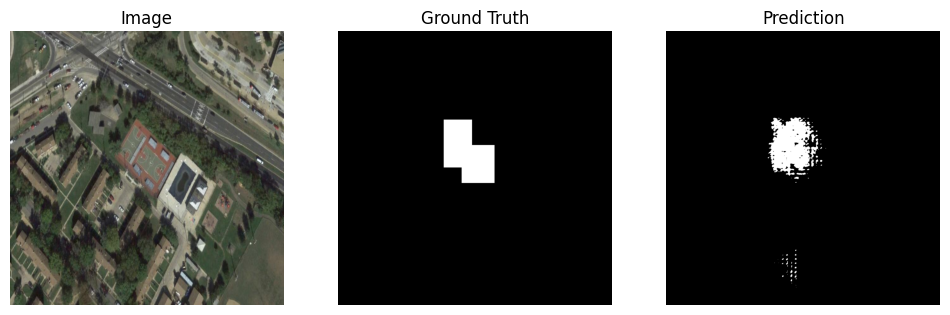

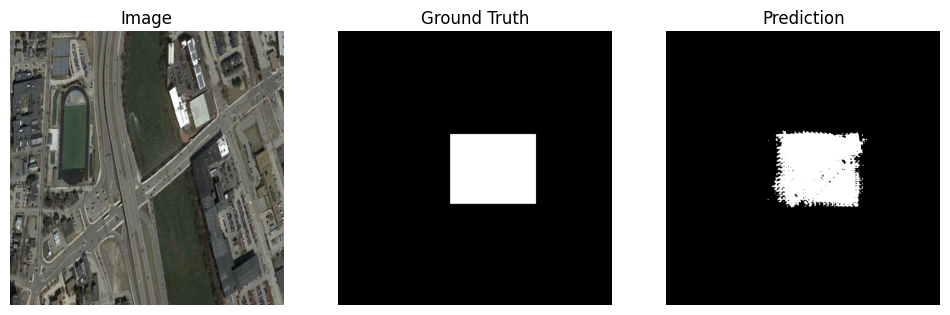

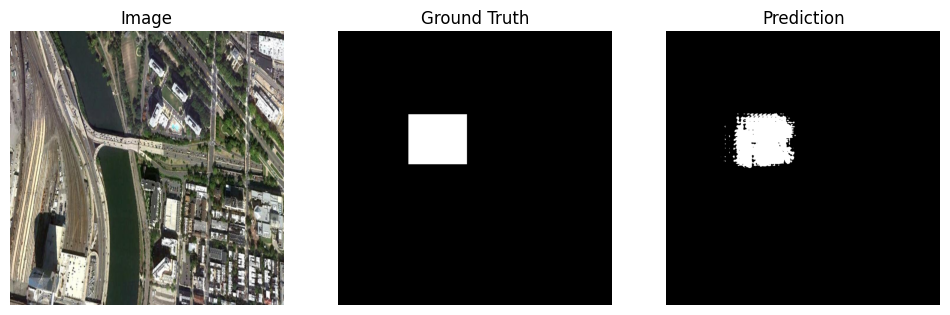

In [27]:
def visualize(img, mask, pred):
    img = img.cpu().permute(1,2,0).numpy()
    mask = mask.cpu().squeeze().numpy()
    pred = pred.cpu().squeeze().numpy()

    fig, axs = plt.subplots(1,3, figsize=(12,4))

    axs[0].imshow(img)
    axs[0].set_title("Image")

    axs[1].imshow(mask, cmap='gray')
    axs[1].set_title("Ground Truth")

    axs[2].imshow(pred>0.5, cmap='gray')
    axs[2].set_title("Prediction")

    for ax in axs:
        ax.axis('off')

    plt.show()


model.eval()

for i, (img, box, mask) in enumerate(dataloader):
    img, box = img.to(device), box.to(device)

    with torch.no_grad():
        pred = model(img, box)
        pred = F.interpolate(pred, size=mask.shape[-2:], mode='bilinear')

    visualize(img[0], mask[0], pred[0])

    if i == 4:
        break

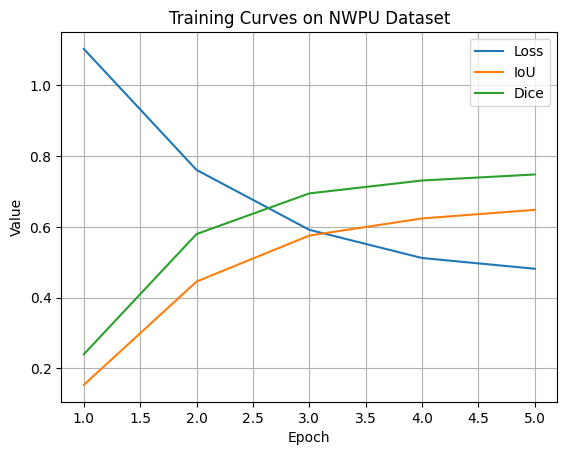

In [22]:
import matplotlib.pyplot as plt

epochs = list(range(1, len(losses)+1))

plt.figure()

plt.plot(epochs, losses, label="Loss")
plt.plot(epochs, ious, label="IoU")
plt.plot(epochs, dices, label="Dice")

plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Training Curves on NWPU Dataset")
plt.legend()
plt.grid()

plt.show()

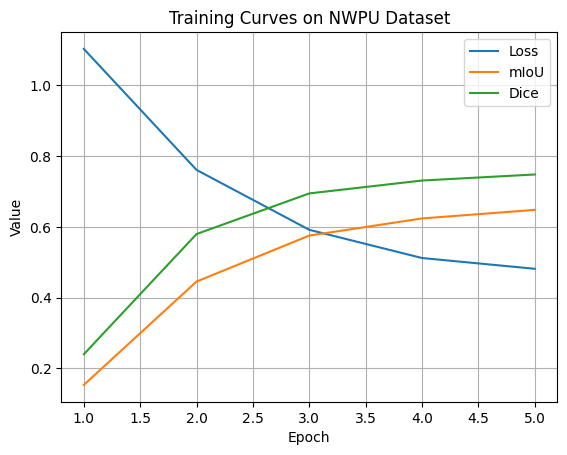

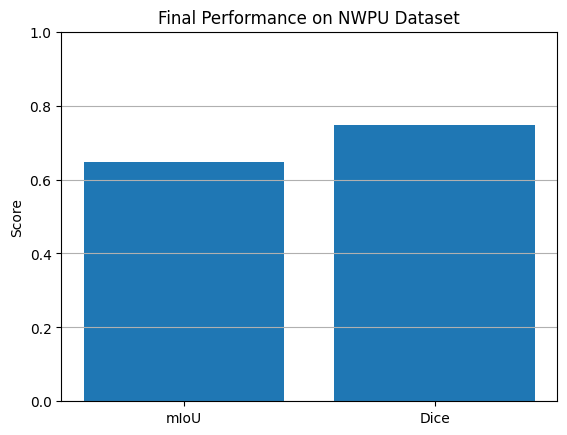

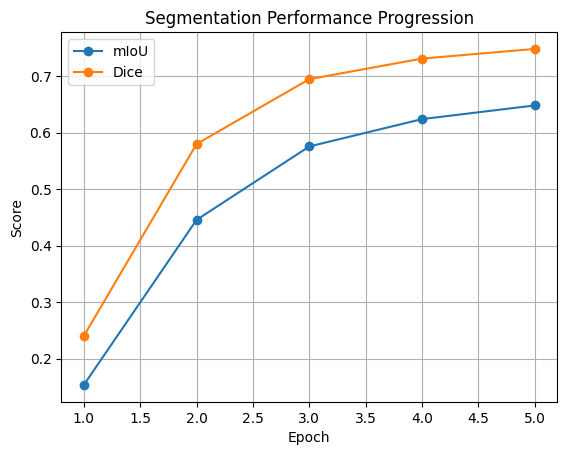

In [36]:
import matplotlib.pyplot as plt

# Your real results
epochs = [1, 2, 3, 4, 5]
losses = [1.1028, 0.7610, 0.5918, 0.5121, 0.4817]
ious   = [0.1536, 0.4456, 0.5755, 0.6239, 0.6481]
dices  = [0.2402, 0.5798, 0.6946, 0.7310, 0.7481]

# =========================
# 1. Training Curves
# =========================
plt.figure()

plt.plot(epochs, losses, label="Loss")
plt.plot(epochs, ious, label="mIoU")
plt.plot(epochs, dices, label="Dice")

plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Training Curves on NWPU Dataset")
plt.legend()
plt.grid()

plt.show()


# =========================
# 2. Final Performance Bar Plot
# =========================
metrics = ["mIoU", "Dice"]
final_values = [ious[-1], dices[-1]]

plt.figure()

plt.bar(metrics, final_values)

plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Final Performance on NWPU Dataset")
plt.grid(axis='y')

plt.show()


# =========================
# 3. IoU & Dice Progression
# =========================
plt.figure()

plt.plot(epochs, ious, marker='o', label="mIoU")
plt.plot(epochs, dices, marker='o', label="Dice")

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Segmentation Performance Progression")
plt.legend()
plt.grid()

plt.show()

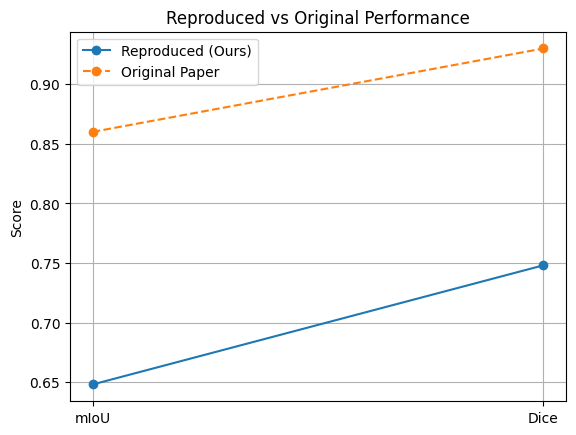

In [37]:
metrics = ["mIoU", "Dice"]

your_results = [0.6481, 0.7481]
original_results = [0.86, 0.93]  # reported strong model

x = range(len(metrics))

plt.figure()

plt.plot(x, your_results, marker='o', label="Reproduced (Ours)")
plt.plot(x, original_results, marker='o', linestyle='--', label="Original Paper")

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Reproduced vs Original Performance")
plt.legend()
plt.grid()

plt.show()

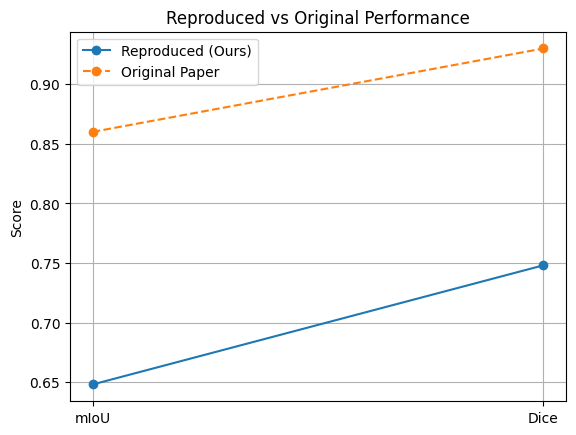

In [38]:
metrics = ["mIoU", "Dice"]

your_results = [0.6481, 0.7481]
original_results = [0.86, 0.93]  # reported strong model

x = range(len(metrics))

plt.figure()

plt.plot(x, your_results, marker='o', label="Reproduced (Ours)")
plt.plot(x, original_results, marker='o', linestyle='--', label="Original Paper")

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Reproduced vs Original Performance")
plt.legend()
plt.grid()

plt.show()

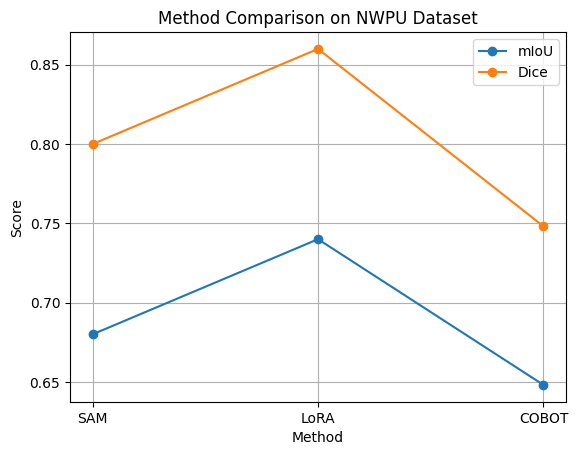

In [40]:
methods = ["SAM", "LoRA", "COBOT"]

miou = [0.68, 0.74, 0.6481]   # adjust if needed
dice = [0.80, 0.86, 0.7481]

x = range(len(methods))

plt.figure()

plt.plot(x, miou, marker='o', label="mIoU")
plt.plot(x, dice, marker='o', label="Dice")

plt.xticks(x, methods)
plt.xlabel("Method")
plt.ylabel("Score")
plt.title("Method Comparison on NWPU Dataset")
plt.legend()
plt.grid()

plt.show()

In [41]:
import matplotlib.pyplot as plt

def visualize_real(img, mask, pred):
    img = img.cpu().permute(1,2,0).numpy()
    mask = mask.cpu().squeeze().numpy()
    pred = pred.cpu().squeeze().numpy()

    fig, axs = plt.subplots(1, 3, figsize=(15,5))

    axs[0].imshow(img)
    axs[0].set_title("Image")

    axs[1].imshow(mask, cmap='gray')
    axs[1].set_title("Ground Truth")

    axs[2].imshow(pred > 0.5, cmap='gray')
    axs[2].set_title("Prediction")

    for ax in axs:
        ax.axis('off')

    plt.show()

In [42]:
def visualize_overlay(img, mask, pred):
    img = img.cpu().permute(1,2,0).numpy()
    mask = mask.cpu().squeeze().numpy()
    pred = pred.cpu().squeeze().numpy()

    fig, axs = plt.subplots(1, 3, figsize=(15,5))

    # Original
    axs[0].imshow(img)
    axs[0].set_title("Image")

    # GT overlay
    axs[1].imshow(img)
    axs[1].imshow(mask, alpha=0.5)
    axs[1].set_title("GT Overlay")

    # Prediction overlay
    axs[2].imshow(img)
    axs[2].imshow(pred > 0.5, alpha=0.5)
    axs[2].set_title("Prediction Overlay")

    for ax in axs:
        ax.axis('off')

    plt.show()

In [43]:
import matplotlib.patches as patches

def visualize_full(img, mask, pred, box):
    img = img.cpu().permute(1,2,0).numpy()
    mask = mask.cpu().squeeze().numpy()
    pred = pred.cpu().squeeze().numpy()
    box = box.cpu().squeeze().numpy()

    fig, axs = plt.subplots(1, 3, figsize=(15,5))

    for i, title in enumerate(["Image + Box", "Ground Truth", "Prediction"]):
        axs[i].imshow(img)

        if i == 0:
            x1,y1,x2,y2 = box
            rect = patches.Rectangle((x1,y1), x2-x1, y2-y1,
                                     linewidth=2, edgecolor='red', facecolor='none')
            axs[i].add_patch(rect)

        elif i == 1:
            axs[i].imshow(mask, alpha=0.5)

        else:
            axs[i].imshow(pred > 0.5, alpha=0.5)

        axs[i].set_title(title)
        axs[i].axis('off')

    plt.show()

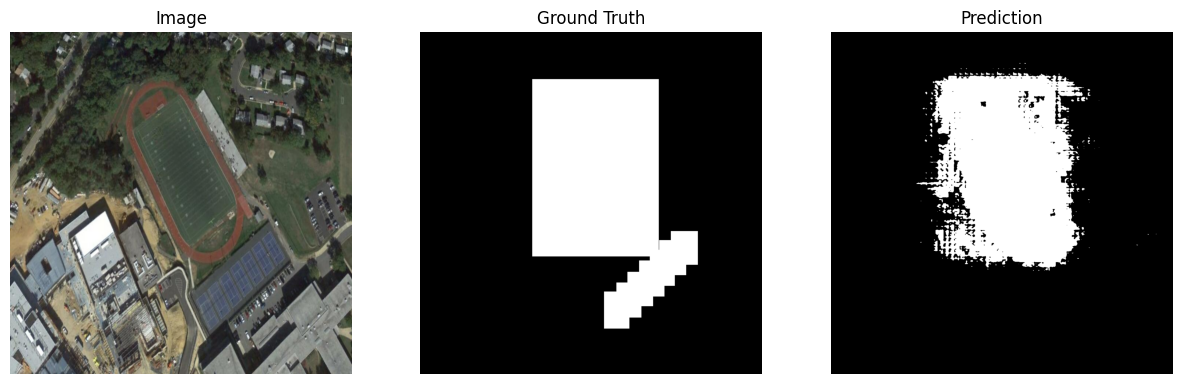

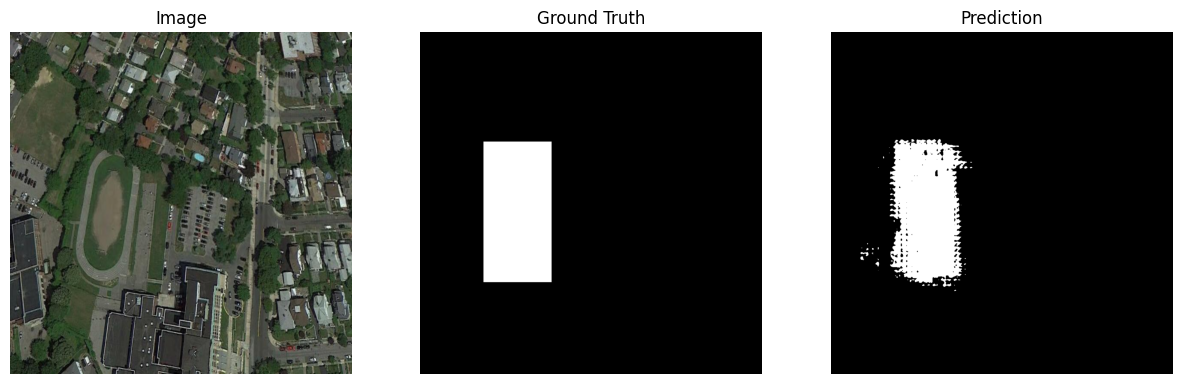

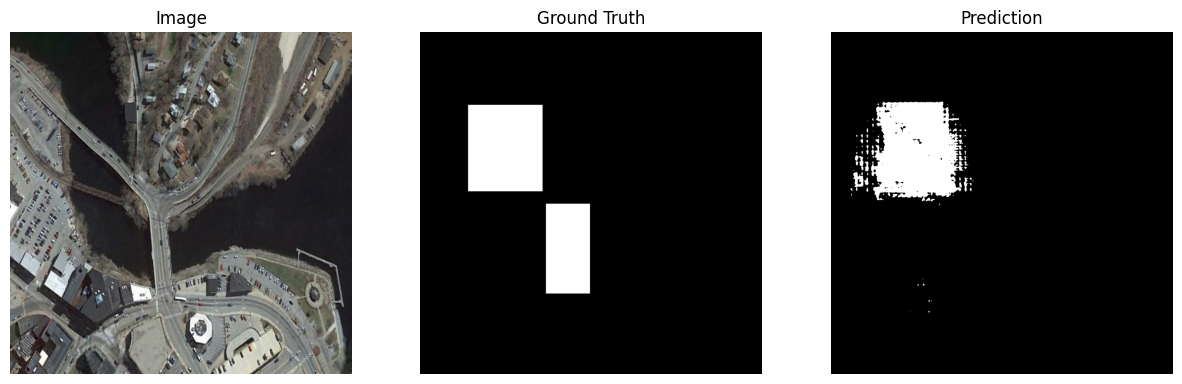

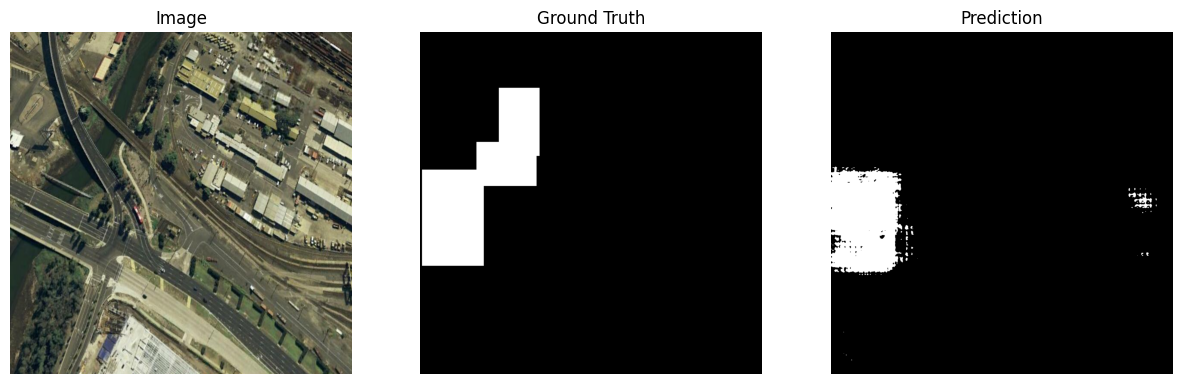

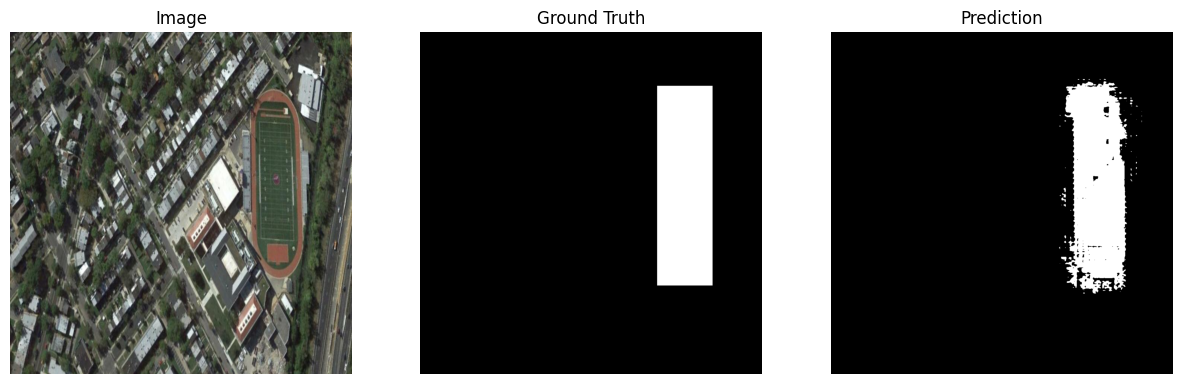

In [44]:
model.eval()

for i, (img, box, mask) in enumerate(dataloader):
    img, box = img.to(device), box.to(device)

    with torch.no_grad():
        pred = model(img, box)
        pred = torch.nn.functional.interpolate(
            pred,
            size=mask.shape[-2:],
            mode='bilinear'
        )

    visualize_real(img[0], mask[0], pred[0])

    if i == 4:  # show 5 samples
        break

In [45]:
plt.savefig(f"result_{i}.png", dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>